# 02 — Experiment 1: postural baseline

**E1A** supine, **E1B** sitting, **E1C** standing — steady-state segments.

**Deliverables**:
- Figure 1.1 — 1×3 RR tachograms (**150 s** representative display window;
  metrics from **full 5 min**), short posture titles and HR/SDNN/RMSSD per panel.
- Figure 1.2 — ECG PSD **stacked panels** per posture (linear y, extra 0.7 Hz
  high-pass) with each condition's HR-harmonic comb ($f_0\ldots 5f_0$).
- Figure 1.3 — RR **tachogram + PSD** grid (2×3) with high-contrast VLF/LF/HF
  fills, **per-column log PSD** y-scale, shared RR y-scale, Task-Force inset
  (ms², n.u., LF/HF), and LF/HF **peak** annotations.
- Figure 1.4 — **sliding-window duration-effect sweep on E1A** showing why
  short windows (30 s) are unreliable (high CV) vs long windows (300 s, low
  CV), per Task Force recommendation of ≥ 5 min for reliable HF.
- Table 1.1 — full metric matrix across E1A–C.

In [19]:
from __future__ import annotations

import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import config as cfg
from src import pipeline as P
from src import plotting as PL

PL.apply_style()
warnings.filterwarnings('ignore', category=RuntimeWarning)

FIG_DIR = REPO_ROOT / 'outputs' / 'figures'
TBL_DIR = REPO_ROOT / 'outputs' / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)
print('Setup complete. Sessions available:', len(cfg.SESSION_MAP))

Setup complete. Sessions available: 14


## 1. Run steady-state pipeline on E1A–C

In [20]:
KEYS = ["E1A", "E1B", "E1C"]
# Short pose labels for figures / table (no protocol or window commentary)
E1_FIG_POSE = {"E1A": "supine", "E1B": "sitting", "E1C": "standing"}
results = {k: P.analyze_steady_state(k) for k in KEYS}
for k, r in results.items():
    print(f"{k}: peaks scipy={r.peaks_scipy.size}, NK={r.peaks_nk.size}  "
          f"HR={r.td_hrv['mean_hr_bpm']:.1f} SDNN={r.td_hrv['sdnn_ms']:.1f}")

E1A: peaks scipy=269, NK=268  HR=54.0 SDNN=81.5
E1B: peaks scipy=280, NK=279  HR=56.1 SDNN=56.6
E1C: peaks scipy=397, NK=396  HR=79.7 SDNN=41.8


## 2. Figure 1.1 — 1×3 RR tachograms

為避免 300 s 全長在 1×3 排版中線條過密、細節不可讀，此處採 **計算視窗（5 min）** 與 **展示視窗（代表性 150 s）** 分離：波形僅顯示前 150 s，**HR / SDNN / RMSSD** 仍由完整錄音計算。圖下方英文註記可併入投稿 **Figure caption**，以符合審稿對披露一致性的期待。

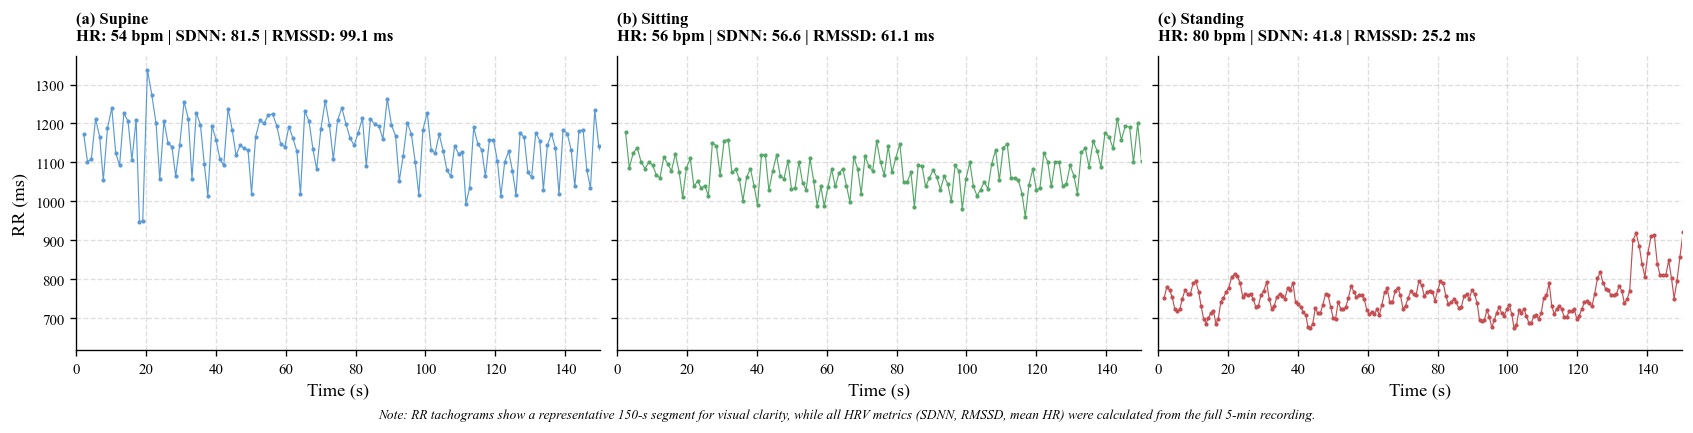

In [21]:
import matplotlib.pyplot as plt

# 1. 統一 IEEE 期刊字體設定
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

KEYS = ["E1A", "E1B", "E1C"]
# 簡化標題，移除非必要的備註，這應該放在論文內文
E1_TACH_LABELS = {
    "E1A": "(a) Supine",
    "E1B": "(b) Sitting",
    "E1C": "(c) Standing",
}

# 展示視窗（秒）：僅影響 X 軸可視範圍；指標仍來自完整 5 min（見 fig.supxlabel）
DISPLAY_WINDOW_S = 150

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True, constrained_layout=True)

for ax, key in zip(axes, KEYS):
    r = results[key]
    td = r.td_hrv

    # PL.plot_rr_tachogram 已使用 linewidth=0.7（期刊常用細線）
    PL.plot_rr_tachogram(r.rr_ms_nk, r.rr_times_nk, ax=ax, color=PL.STYLE_COLORS[key])
    ax.set_xlim(0, DISPLAY_WINDOW_S)

    title_str = (
        f"{E1_TACH_LABELS[key]}\n"
        f"HR: {td['mean_hr_bpm']:.0f} bpm | SDNN: {td['sdnn_ms']:.1f} | RMSSD: {td['rmssd_ms']:.1f} ms"
    )
    ax.set_title(title_str, loc='left', fontweight='bold', fontsize=10, pad=10)

    ax.grid(True, linestyle='--', alpha=0.4)
    if ax != axes[0]:
        ax.set_ylabel("")  # 隱藏共用 Y 軸的重複標籤

fig.supxlabel(
    "Note: RR tachograms show a representative 150-s segment for visual clarity, "
    "while all HRV metrics (SDNN, RMSSD, mean HR) were calculated from the full 5-min recording.",
    fontsize=8,
    style="italic",
)
plt.show()

## 3. Figure 1.2 — ECG PSD stacked panels, per-posture harmonic comb

Each condition has its own mean HR, so the harmonic comb ($f_0$ = HR/60 Hz)
sits at a different frequency in every panel. **Linear** PSD (Welch on
ECG after an extra **0.7 Hz high-pass** to strip residual baseline), **y-axis**
zoomed from the max in 0.5–5 Hz; red dotted lines at $f_0\ldots 5f_0$.

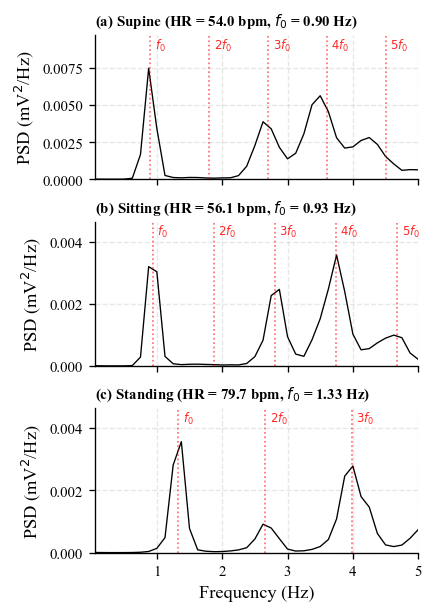

In [22]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from matplotlib.transforms import blended_transform_factory

# Extra high-pass on top of pipeline filtering: removes residual baseline / sub-0.7 Hz energy
# before Welch PSD (journal-style linear y-scale).
_HP_ORDER = 4
_HP_CUTOFF_HZ = 0.7

fig, axes = plt.subplots(len(KEYS), 1, figsize=(3.5, 5), sharex=True, constrained_layout=True)

for i, (ax, key) in enumerate(zip(axes, KEYS)):
    r = results[key]
    sos_hp = butter(_HP_ORDER, _HP_CUTOFF_HZ, btype="highpass", fs=cfg.FS, output="sos")
    ecg_hp = sosfiltfilt(sos_hp, r.ecg_filt)

    f, p = P.ecg_psd(ecg_hp, fs=cfg.FS)

    hr = float(r.td_hrv["mean_hr_bpm"])
    f0 = hr / 60.0

    ax.plot(f, p, color="black", lw=0.8)

    mask = (f > 0.5) & (f < 5.0)
    if np.any(mask):
        max_p_in_range = float(np.max(p[mask]))
        if max_p_in_range > 0:
            ax.set_ylim(0.0, max_p_in_range * 1.3)

    harmonic_trans = blended_transform_factory(ax.transData, ax.transAxes)
    x_lo, x_hi = 0.05, 5.0
    for harmonic in range(1, 6):
        fx = f0 * harmonic
        if not (x_lo <= fx <= x_hi):
            continue
        ax.axvline(fx, color="red", linestyle=":", alpha=0.6, lw=1)
        h_label = r"$f_0$" if harmonic == 1 else rf"${harmonic}f_0$"
        label_x = fx + 0.07
        ax.text(
            label_x,
            0.99,
            h_label,
            transform=harmonic_trans,
            ha="left",
            va="top",
            fontsize=7,
            color="red",
            alpha=0.85,
            clip_on=False,
        )

    condition_name = ["Supine", "Sitting", "Standing"][i]
    ax.set_title(
        f"({chr(97 + i)}) {condition_name} (HR = {hr:.1f} bpm, $f_0$ = {f0:.2f} Hz)",
        loc="left",
        fontweight="bold",
        fontsize=9,
    )
    ax.set_ylabel(r"PSD (mV$^2$/Hz)")
    ax.set_xlim(0.05, 5.0)
    ax.grid(True, linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Frequency (Hz)")
PL.save_figure(fig, "nb02_fig02_ecg_psd_harmonics.pdf")
plt.show()

## 4. Figure 1.3 — RR tachogram + PSD grid (journal-style)

Overlaying all three postures on one PSD axis hides posture effects on **total
power**. This figure uses a **2×3 grid** (E1A–C): tachogram above, PSD below,
**shared RR y-limits** across columns; **each PSD column has its own y-scale**
(log by default) so orthostatic reductions in total power are not visually
flattened against a large supine peak.

- **RR y-axis**: global min/max across conditions (with small padding).
- **PSD y-axis**: per-column autoscale on 0–0.5 Hz view, **log** scale (aligned
  with Task Force–style log–log spectrum figures).
- **Grayscale VLF/LF/HF** fills under the PSD curve (strong contrast); band
  masks follow pipeline integration `[lo, hi)`.
- **Tachogram**: short title + HR / SDNN / RMSSD in a text box; **PSD**:
  inset table (ms², n.u., LF/HF) and **LF / HF peak** annotations (HF labelled
  with ~breaths/min for RSA).
- **Serif** typography for this figure only (`plt.rc_context`), via
  `plot_rr_tachogram_psd_grid` in `src/plotting.py`.

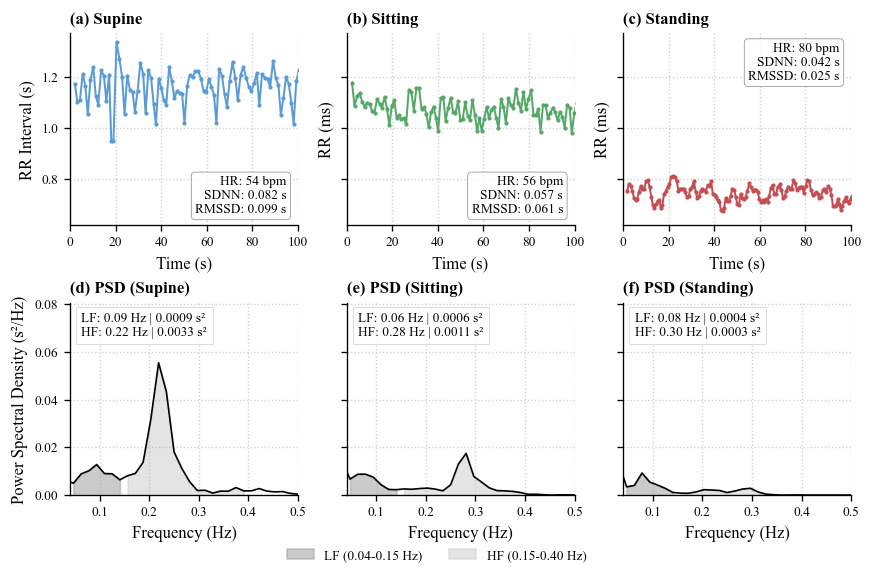

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# 1. 針對 IEEE 雙欄跨欄圖表的標準設定 (真實印刷尺寸約 7.16 英吋寬)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'], 
    'font.size': 9,       
    'axes.labelsize': 10, 
    'axes.titlesize': 10, 
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

KEYS = ["E1A", "E1B", "E1C"]
E1_TACH_LABELS = {
    "E1A": "(a) Supine",
    "E1B": "(b) Sitting",
    "E1C": "(c) Standing",
}
DISPLAY_WINDOW_S = 100

# 2. 預計算：RR 以秒表示，PSD 為 s²/Hz
psd_results = {}
global_max_psd = 0
for key in KEYS:
    r = results[key]
    f, p = P.rr_psd(r.rr_ms_nk / 1000.0, r.rr_times_nk)
    psd_results[key] = (f, p)
    mask = (f >= 0.04) & (f <= 0.5)
    if mask.any():
        global_max_psd = max(global_max_psd, np.max(p[mask]))

# 預留上方空間給資訊框
global_max_psd *= 1.45 

# 3. 調整 figsize 為 7.16 英吋寬
fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.5), constrained_layout=True, sharey="row")

for i, key in enumerate(KEYS):
    r = results[key]
    td = r.td_hrv
    fd = r.fd_hrv
    f, p = psd_results[key]
    
    # ==========================================
    # 上排 (a-c)：RR Tachogram
    # ==========================================
    ax_t = axes[0, i]
    PL.plot_rr_tachogram(r.rr_ms_nk / 1000.0, r.rr_times_nk, ax=ax_t, color=PL.STYLE_COLORS[key])
    if ax_t.lines:
        ax_t.lines[0].set_linewidth(1.2)
    ax_t.set_xlim(0, DISPLAY_WINDOW_S)

    ax_t.set_title(E1_TACH_LABELS[key], loc='left', fontweight='bold', pad=6)
    
    td_text = (f"HR: {td['mean_hr_bpm']:.0f} bpm\n"
               f"SDNN: {td['sdnn_ms'] / 1000.0:.3f} s\n"
               f"RMSSD: {td['rmssd_ms'] / 1000.0:.3f} s")
    _ty, _tva = (0.05, "bottom") if i == 0 or i == 1 else (0.95, "top")
    ax_t.text(0.95, _ty, td_text, transform=ax_t.transAxes, fontsize=8,
              verticalalignment=_tva, horizontalalignment="right",
              bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="gray", lw=0.5))

    ax_t.grid(True, linestyle=':', alpha=0.6) 
    if i == 0:
        ax_t.set_ylabel("RR Interval (s)")

    # ==========================================
    # 下排 (d-f)：PSD (頻域)
    # ==========================================
    ax_f = axes[1, i]
    ax_f.plot(f, p, color='black', lw=1.0)
    ax_f.set_xlim(0.04, 0.5)
    ax_f.set_ylim(0, global_max_psd)

    m_lf = (f >= 0.04) & (f < 0.15)
    m_hf = (f >= 0.15) & (f < 0.40)
    
    ax_f.fill_between(f, p, where=m_lf, color='#A9A9A9', alpha=0.6, label='LF (0.04-0.15 Hz)')
    ax_f.fill_between(f, p, where=m_hf, color='#D3D3D3', alpha=0.6, label='HF (0.15-0.40 Hz)')

    # 提取數值
    lf_hz = float(fd["lf_peak_hz"])
    hf_hz = float(fd["hf_peak_hz"])
    lf_s2 = float(fd["lf_ms2"]) / 1e6
    hf_s2 = float(fd["hf_ms2"]) / 1e6
    
    # 頻帶功率以 s² 顯示（與以秒為單位之 RR PSD 一致）
    fd_text = (f"LF: {lf_hz:.2f} Hz | {lf_s2:.4f} s²\n"
               f"HF: {hf_hz:.2f} Hz | {hf_s2:.4f} s²")
    
    ax_f.text(0.05, 0.95, fd_text, transform=ax_f.transAxes, fontsize=8,
              verticalalignment='top', horizontalalignment='left',
              bbox=dict(boxstyle='square,pad=0.4', facecolor='white', alpha=0.9, edgecolor='lightgray', lw=0.5))

    label_f = ["(d) PSD (Supine)", "(e) PSD (Sitting)", "(f) PSD (Standing)"][i]
    ax_f.set_title(label_f, loc='left', fontweight='bold', pad=6)
    ax_f.set_xlabel("Frequency (Hz)")
    
    if i == 0:
        ax_f.set_ylabel("Power Spectral Density (s²/Hz)")

    ax_f.grid(True, linestyle=':', alpha=0.6)

# 修正 2：抽取 ax_f 的 Legend，放置在全圖表正下方 (Figure-level legend)
handles, labels = axes[1, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), frameon=False)

PL.save_figure(fig, "nb02_fig03_rr_psd_postural.pdf")
plt.show()

## 5. Duration-effect sweep on E1A

Sliding window with 75 % overlap across `[30, 60, 120, 180, 240, 300] s`.
For each W we compute SDNN, LF, HF on every sub-window, then report
mean ± std and CV %.

Expected checkpoints (T = 300 s, step = W/4):
`W=30 → 37, W=60 → 17, W=120 → 7, W=180 → 4, W=240 → 2, W=300 → 1` (full).

mean                      std                  cv_pct          \
metric     hf_ms2  lf_ms2 sdnn_ms   hf_ms2   lf_ms2 sdnn_ms hf_ms2  lf_ms2   
window_s                                                                     
30        2842.59  658.46   71.23  1564.35  1155.66   18.79  55.03  175.51   
60        3067.17  798.42   73.50  1237.19   947.85   12.88  40.34  118.72   
120       3003.18  710.04   71.64   749.76   603.04    7.68  24.97   84.93   
180       2793.52  442.36   72.20   100.80   120.37    4.20   3.61   27.21   
240       3108.03  775.27   74.94   306.52   295.69    4.74   9.86   38.14   
300       3208.79  874.10   79.89      NaN      NaN     NaN    NaN     NaN   

                 n_windows                 
metric   sdnn_ms    hf_ms2 lf_ms2 sdnn_ms  
window_s                                   
30         26.38      37.0   37.0    37.0  
60         17.53      17.0   17.0    17.0  
120        10.71       7.0    7.0     7.0  
180         5.82       3.0    3.0     3.0  
240         6.32       2.0    2.0     2.0  
300          NaN       1.0    1.0     1.0

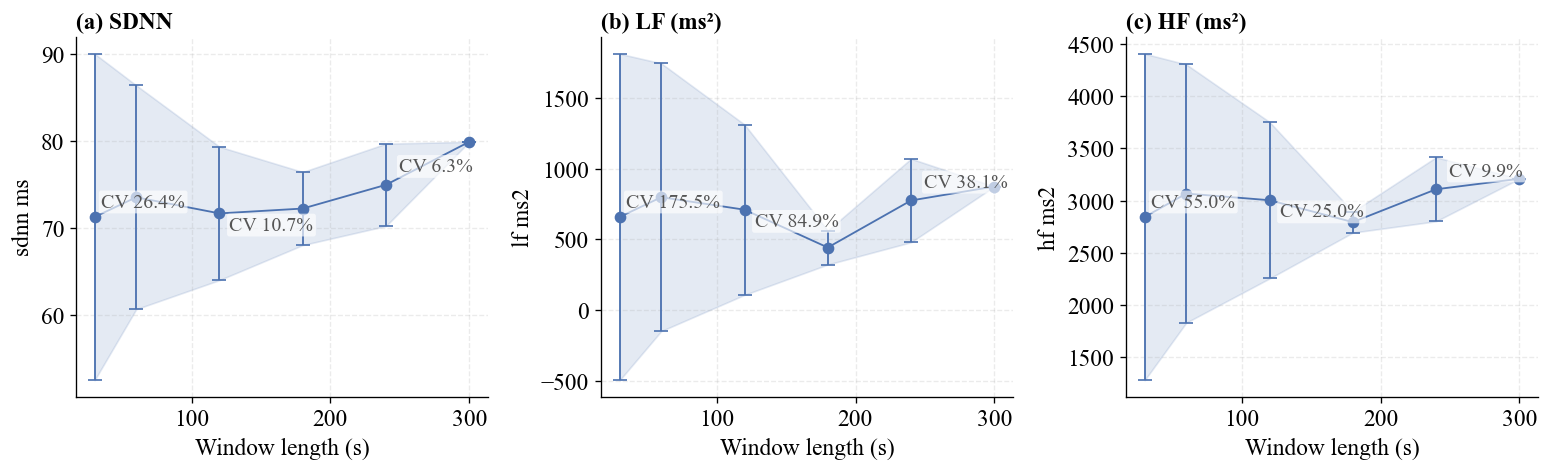

In [24]:
r_e1a = results["E1A"]
df_sweep = P.duration_effect_sweep(r_e1a.ecg_filt, fs=cfg.FS)
display(df_sweep.pivot(index="window_s", columns="metric",
                       values=["mean","std","cv_pct","n_windows"]).round(2))

fig = plt.figure(figsize=(13, 4))
PL.plot_duration_sweep(df_sweep, metrics=("sdnn_ms", "lf_ms2", "hf_ms2"), fig=fig, fontsize=14)
PL.save_figure(fig, "nb02_fig04_duration_effect.pdf")
plt.show()
df_sweep.to_csv(TBL_DIR / "e1a_duration_sweep.csv", index=False)

## 6. Table 1.1 — Full metric matrix E1A–C

In [25]:
table11 = []
for key in KEYS:
    r = results[key]
    f_nk = r.hrv_full.iloc[0] if r.hrv_full is not None else None
    row = {
        "Condition":            key,
        "Posture":              E1_FIG_POSE[key].title(),
        "Mean HR (bpm)":        r.td_hrv["mean_hr_bpm"],
        "Mean RR (ms)":         r.td_hrv["mean_rr_ms"],
        "SDNN (ms)":            r.td_hrv["sdnn_ms"],
        "RMSSD (ms)":           r.td_hrv["rmssd_ms"],
        "pNN50 (%)":            r.td_hrv["pnn50_pct"],
        "Total Power (ms²)":    r.fd_hrv["total_power_ms2"],
        "VLF (ms²)":            r.fd_hrv["vlf_ms2"],
        "LF (ms²)":             r.fd_hrv["lf_ms2"],
        "HF (ms²)":             r.fd_hrv["hf_ms2"],
        "LF (n.u.)":            r.fd_hrv["lf_nu"],
        "HF (n.u.)":            r.fd_hrv["hf_nu"],
        "LF/HF":                r.fd_hrv["lf_hf_ratio"],
        "HF peak (Hz)":         r.fd_hrv["hf_peak_hz"],
        "n peaks (NK2)":        r.peaks_nk.size,
        "Artifact rate (%)":    ((r.nk_stats["ectopic"] + r.nk_stats["missed"]
                                  + r.nk_stats["extra"] + r.nk_stats["longshort"])
                                 / max(r.peaks_nk.size, 1) * 100.0),
    }
    table11.append(row)
df_t11 = pd.DataFrame(table11)
df_t11.to_csv(TBL_DIR / "table_1_1_postural.csv", index=False)
df_t11.style.set_caption(
    "Table 1.1 — Postural HRV metrics (E1A-E1C). "
    "Band powers follow Task Force 1996: VLF 0.003–0.04, LF 0.04–0.15, "
    "HF 0.15–0.4 Hz. n.u. = 100·X / (LF+HF)."
).format({
    "Mean HR (bpm)": "{:.1f}", "Mean RR (ms)": "{:.1f}",
    "SDNN (ms)": "{:.1f}", "RMSSD (ms)": "{:.1f}", "pNN50 (%)": "{:.1f}",
    "Total Power (ms²)": "{:,.0f}",
    "VLF (ms²)": "{:,.0f}", "LF (ms²)": "{:,.0f}", "HF (ms²)": "{:,.0f}",
    "LF (n.u.)": "{:.1f}", "HF (n.u.)": "{:.1f}", "LF/HF": "{:.2f}",
    "HF peak (Hz)": "{:.3f}", "Artifact rate (%)": "{:.2f}",
})

,Condition,Posture,Mean HR (bpm),Mean RR (ms),SDNN (ms),RMSSD (ms),pNN50 (%),Total Power (ms²),VLF (ms²),LF (ms²),HF (ms²),LF (n.u.),HF (n.u.),LF/HF,HF peak (Hz),n peaks (NK2),Artifact rate (%)
0,E1A,Supine,54.0,1116.9,81.5,99.1,62.2,"4,326",162,907,"3,257",21.8,78.2,0.28,0.219,268,0.37
1,E1B,Sitting,56.1,1072.6,56.6,61.1,43.5,"2,017",293,601,"1,123",34.9,65.1,0.53,0.281,279,0.00
2,E1C,Standing,79.7,755.3,41.8,25.2,2.8,"1,048",289,448,311,59.0,41.0,1.44,0.297,396,0.00


,Condition,N beats,Mean RR (ms),Mean HR (bpm),SD1 (ms),SD2 (ms),SD1/SD2
0,(a) Supine,267,1117.90,53.67,68.33,89.97,0.76
1,(b) Sitting,278,1072.40,55.95,42.18,67.34,0.63
2,(c) Standing,395,755.26,79.44,17.86,56.42,0.32


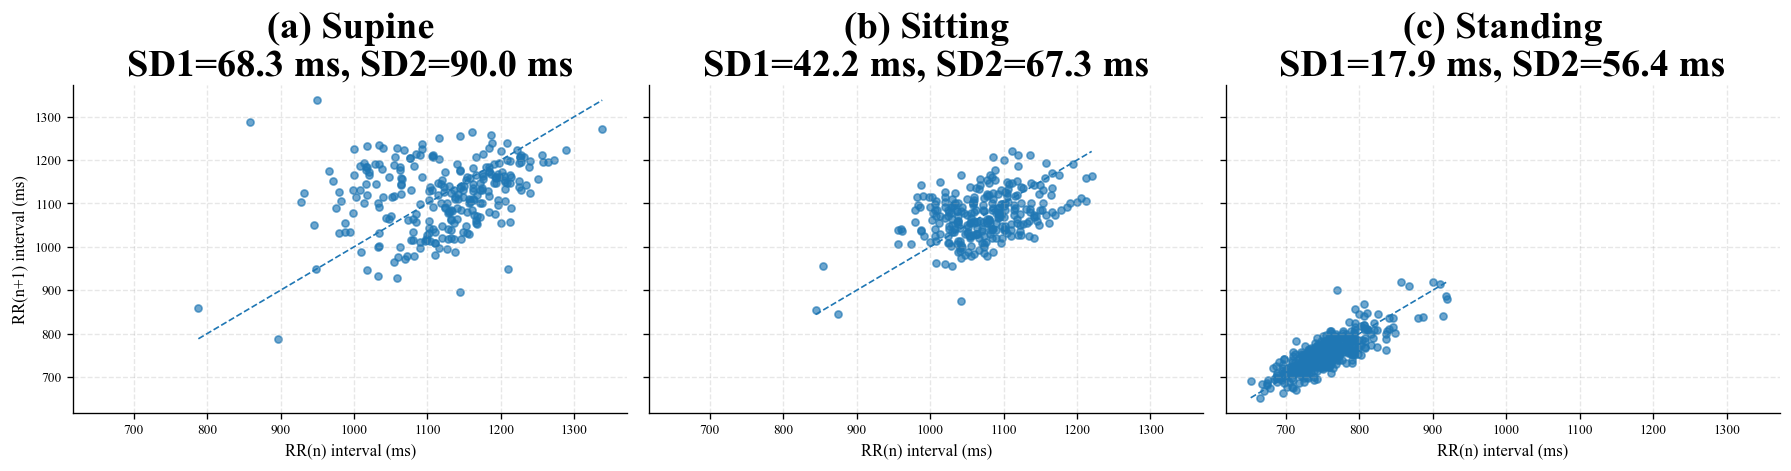

In [26]:
# ============================================================
# Experiment 1 - Poincaré / Lorenz Plot Analysis
# Purpose:
# Visualize beat-to-beat RR interval geometry across postures.
# This provides an intuitive geometric view of HRV reduction
# from supine -> sitting -> standing.
# ============================================================

import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ensure repo is importable and pipeline is available (skip if you already ran the setup cell).
if "P" not in globals():
    _REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    if str(_REPO) not in sys.path:
        sys.path.insert(0, str(_REPO))
    from src import pipeline as P  # noqa: E402

KEYS = ["E1A", "E1B", "E1C"]
# Same steady-state analysis as §1; fill only if not already computed this session.
if "results" not in globals():
    results = {k: P.analyze_steady_state(k) for k in KEYS}

# ------------------------------------------------------------
# 1. RR (ms): E1A–C → supine / sitting / standing
# ------------------------------------------------------------

rr_dict = {
    "(a) Supine": results["E1A"].rr_ms_nk,
    "(b) Sitting": results["E1B"].rr_ms_nk,
    "(c) Standing": results["E1C"].rr_ms_nk,
}

# ------------------------------------------------------------
# 2. Function to compute Poincaré plot metrics
# ------------------------------------------------------------

def compute_poincare_metrics(rr_ms):
    """
    Compute SD1 and SD2 from RR intervals.

    SD1 reflects short-term beat-to-beat variability.
    It is closely related to RMSSD.

    SD2 reflects longer-term variability along the identity line.
    """

    rr_ms = np.asarray(rr_ms)
    rr_ms = rr_ms[np.isfinite(rr_ms)]

    rr_n = rr_ms[:-1]
    rr_n1 = rr_ms[1:]

    diff_rr = rr_n1 - rr_n

    # Standard Poincaré metrics
    sd1 = np.sqrt(np.var(diff_rr, ddof=1) / 2)
    sd2 = np.sqrt(2 * np.var(rr_ms, ddof=1) - 0.5 * np.var(diff_rr, ddof=1))

    sd_ratio = sd1 / sd2 if sd2 != 0 else np.nan

    return {
        "Mean RR (ms)": np.mean(rr_ms),
        "Mean HR (bpm)": 60000 / np.mean(rr_ms),
        "SD1 (ms)": sd1,
        "SD2 (ms)": sd2,
        "SD1/SD2": sd_ratio,
        "N beats": len(rr_ms),
    }

# ------------------------------------------------------------
# 3. Compute summary table
# ------------------------------------------------------------

poincare_summary = []

for condition, rr_ms in rr_dict.items():
    metrics = compute_poincare_metrics(rr_ms)
    metrics["Condition"] = condition
    poincare_summary.append(metrics)

poincare_summary = pd.DataFrame(poincare_summary)
poincare_summary = poincare_summary[
    ["Condition", "N beats", "Mean RR (ms)", "Mean HR (bpm)", "SD1 (ms)", "SD2 (ms)", "SD1/SD2"]
]

display(poincare_summary.round(2))

# ------------------------------------------------------------
# 4. Plot Poincaré plots across postures
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (condition, rr_ms) in zip(axes, rr_dict.items()):
    rr_ms = np.asarray(rr_ms)
    rr_ms = rr_ms[np.isfinite(rr_ms)]

    rr_n = rr_ms[:-1]
    rr_n1 = rr_ms[1:]

    metrics = compute_poincare_metrics(rr_ms)

    ax.scatter(rr_n, rr_n1, s=18, alpha=0.65)

    # Identity line: RR(n+1) = RR(n)
    min_rr = min(np.min(rr_n), np.min(rr_n1))
    max_rr = max(np.max(rr_n), np.max(rr_n1))
    ax.plot([min_rr, max_rr], [min_rr, max_rr], linestyle="--", linewidth=1)

    ax.set_title(
        f"{condition}\n"
        f"SD1={metrics['SD1 (ms)']:.1f} ms, "
        f"SD2={metrics['SD2 (ms)']:.1f} ms",
        fontsize=23,
    )

    ax.set_xlabel("RR(n) interval (ms)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("RR(n+1) interval (ms)")

plt.tight_layout()
PL.save_figure(fig, "nb02_fig05_poincare_plot.pdf")
plt.show()

## 7. Orthostatic monotonicity check

In [27]:
ordered = df_t11.set_index("Condition").loc[["E1A", "E1B", "E1C"]]
print("Orthostatic ramp E1A (supine) -> E1B (sitting) -> E1C (standing):")
print(f"  HR:     {list(ordered['Mean HR (bpm)'].round(1))}  (expect monotonic up)")
print(f"  HF:     {list(ordered['HF (ms²)'].round(0))}  (expect monotonic down)")
print(f"  LF/HF:  {list(ordered['LF/HF'].round(2))}  (expect monotonic up)")

# save full HRV index DataFrame for 06_integration
pd.concat([results[k].hrv_full.assign(key=k) for k in KEYS], axis=0).to_csv(
    TBL_DIR / "e1_hrv_full.csv", index=False)

Orthostatic ramp E1A (supine) -> E1B (sitting) -> E1C (standing):
  HR:     [54.0, 56.1, 79.7]  (expect monotonic up)
  HF:     [3257.0, 1123.0, 311.0]  (expect monotonic down)
  LF/HF:  [0.28, 0.53, 1.44]  (expect monotonic up)
